<a href="https://colab.research.google.com/github/Yusra-Azeem/Exoplanet/blob/main/Habitability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ── Install all required libraries ──────────────────────────────
# pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn
# pip install xgboost lightgbm joblib flask flask-cors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv('phl_exoplanet_catalog_2019.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape: {df.shape}")          # (~4048 rows, 112 columns)
print(f"Columns: {df.columns.tolist()[:10]} ...")

print("\nTarget column — P_HABITABLE:")
print(df['P_HABITABLE'].value_counts())
# 0    3981  ← not habitable
# 1      24  ← conservatively habitable (rocky, liquid water likely)
# 2      33  ← optimistically habitable (ocean world, mini-Neptune possible)

FileNotFoundError: [Errno 2] No such file or directory: 'phl_exoplanet_catalog_2019.csv'

In [23]:

# We merge class 1 and 2 into a single "habitable" class
# because the goal is: CAN life exist, not what KIND of habitable
df['HABITABLE'] = df['P_HABITABLE'].apply(lambda x: 1 if x > 0 else 0)
df.drop(columns=['P_HABITABLE'], inplace=True)   # drop original to prevent leakage

print("\nBinary distribution after merge:")
print(df['HABITABLE'].value_counts())

ratio = df['HABITABLE'].value_counts()[0] / df['HABITABLE'].value_counts()[1]
print(f"\nImbalance ratio: {ratio:.1f}:1")
# ~70 habitable out of 4048 total — extreme imbalance (57:1)
# This means accuracy is a USELESS metric — a model predicting "never habitable"
# gets 98.3% accuracy but misses every single habitable planet

print("\nSample rows (habitable only):")
print(df[df['HABITABLE'] == 1][['P_NAME','P_RADIUS_EST','P_TEMP_EQUIL',
                                  'P_ESI','S_TEMPERATURE']].head(5))

# ── Save raw loaded version ───────────────────────────────────────────────────
df.to_csv('df_raw.csv', index=False)
print("\nSaved: df_raw.csv")



Binary distribution after merge:
HABITABLE
0    3993
1      55
Name: count, dtype: int64

Imbalance ratio: 72.6:1

Sample rows (habitable only):
        P_NAME  P_RADIUS_EST  P_TEMP_EQUIL     P_ESI  S_TEMPERATURE
137   GJ 163 c      2.499655     269.09231  0.686705         3500.0
140   GJ 273 b      1.509595     265.80058  0.843422         3382.0
151  GJ 3293 d      2.668393     219.20455  0.619738         3466.0
153  GJ 3323 b      1.226695     265.35756  0.898398         3159.0
159   GJ 357 d      2.344216     199.44790  0.571287         3505.0

Saved: df_raw.csv


In [24]:
# ── Step 02: Data Cleaning (CORRECTED VERSION)
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

os.makedirs('model_artifacts', exist_ok=True)

df = pd.read_csv('df_raw.csv')
print(f"Starting shape: {df.shape}")
print(f"Habitable: {df['HABITABLE'].sum()} | Not: {(df['HABITABLE']==0).sum()}")

Starting shape: (4048, 112)
Habitable: 55 | Not: 3993


In [25]:

# STEP 2a: Drop columns with >40% missing
# FIX 6: Check correlation first — don't drop blindly
# ─────────────────────────────────────────────────────────────────────────────
pct_missing = df.isnull().sum() / len(df)
high_missing_candidates = pct_missing[pct_missing > 0.4].index.tolist()

# Quick check: are any high-missing columns correlated with target?
# If a column is >0.4 missing AND has low correlation → safe to drop
# If it has high correlation → raise threshold or keep
numeric_only = df.select_dtypes(include=[np.number])
if 'HABITABLE' in numeric_only.columns and len(high_missing_candidates) > 0:
    corr_check = numeric_only[
        [c for c in high_missing_candidates if c in numeric_only.columns] + ['HABITABLE']
    ].corr()['HABITABLE'].abs().drop('HABITABLE', errors='ignore')
    high_corr_missing = corr_check[corr_check > 0.1]
    if len(high_corr_missing) > 0:
        print(f"\n⚠ Warning: these >40%-missing columns have correlation > 0.1 with target:")
        print(high_corr_missing)
        print("Consider raising threshold to 60% or keeping them despite missingness.")

# Proceed with drop (adjust threshold here if needed)
cols_to_drop = high_missing_candidates
print(f"\nDropping {len(cols_to_drop)} columns with >40% missing")
df.drop(columns=cols_to_drop, inplace=True)


⚠ Warning: these >40%-missing columns have correlation > 0.1 with target:
P_ECCENTRICITY_ERROR_MAX    0.144204
P_OMEGA_ERROR_MAX           0.172388
P_TPERI                     0.541932
S_AGE                       0.118259
Name: HABITABLE, dtype: float64
Consider raising threshold to 60% or keeping them despite missingness.

Dropping 41 columns with >40% missing


In [26]:
 #STEP 2b: Drop non-predictive ID / metadata columns
# ─────────────────────────────────────────────────────────────────────────────
id_cols = [
    'P_NAME', 'S_NAME', 'P_NAME_KEPLER', 'P_NAME_KOI',
    'S_CONSTELLATION', 'P_DISC', 'P_DISC_METHOD',
    'P_DETECTION', 'P_DETECTION_MASS', 'P_ALT_NAMES'
]
df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)
print(f"After dropping ID cols: {df.shape}")

After dropping ID cols: (4048, 67)


In [27]:
# STEP 2c: Separate numeric and categorical columns
# FIX 2: Do NOT pass categoricals into IterativeImputer
# Imputer treats everything as continuous — it will create invalid
# fractional values for categories (e.g. "G-type"=2, "K-type"=3 → 2.6)
# ─────────────────────────────────────────────────────────────────────────────
# Separate BEFORE any encoding
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from both lists
num_cols = [c for c in num_cols if c != 'HABITABLE']
cat_cols = [c for c in cat_cols if c != 'HABITABLE']

print(f"\nNumeric columns:     {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)} → {cat_cols}")



Numeric columns:     57
Categorical columns: 9 → ['P_UPDATED', 'S_ALT_NAMES', 'P_TYPE', 'S_TYPE_TEMP', 'S_RA_T', 'S_DEC_T', 'P_TYPE_TEMP', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG']


In [50]:


# STEP 2d: Physics-based Mass↔Radius imputation
if 'P_MASS' in df.columns and 'P_RADIUS_EST' in df.columns:
    rocky_mask = df['P_RADIUS_EST'] < 1.23  # only for rocky worlds

    # Fill mass from radius — only for small rocky planets
    missing_mass_rocky = df['P_MASS'].isna() & rocky_mask & df['P_RADIUS_EST'].notna()
    df.loc[missing_mass_rocky, 'P_MASS'] = (
        0.9718 * (df.loc[missing_mass_rocky, 'P_RADIUS_EST'] ** 3.58)
    )

    # Fill radius from mass — only for small rocky planets
    missing_rad_rocky = df['P_RADIUS_EST'].isna() & rocky_mask & df['P_MASS'].notna()
    df.loc[missing_rad_rocky, 'P_RADIUS_EST'] = (
        (df.loc[missing_rad_rocky, 'P_MASS'] / 0.9718) ** (1 / 3.58)
    )

    # For non-rocky planets (gas giants etc.) leave NaN — let IterativeImputer handle
    # IterativeImputer will use all other features (period, flux, star type) to
    # estimate these values, which is more appropriate than wrong physics formulas

    print(f"\nPhysics imputation (rocky only, R < 1.23):")
    print(f"  P_MASS filled:        {missing_mass_rocky.sum()} rows")
    print(f"  P_RADIUS_EST filled:  {missing_rad_rocky.sum()} rows")
    print(f"  Remaining P_MASS NaN: {df['P_MASS'].isna().sum()}")


In [51]:

# STEP 2e: FIX 1 — Train/Test split BEFORE any statistical imputation

y = df['HABITABLE']
X_num = df[num_cols]
X_cat = df[cat_cols] if cat_cols else pd.DataFrame(index=df.index)

X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_num, y,
    test_size=0.2,
    stratify=y,        # preserve 57:1 imbalance ratio in both splits
    random_state=42
)

# Keep the same indices for categorical
X_cat_train = X_cat.loc[X_num_train.index]
X_cat_test  = X_cat.loc[X_num_test.index]

print(f"\nAfter split:")
print(f"  Train: {X_num_train.shape[0]} rows | Habitable: {y_train.sum()}")
print(f"  Test:  {X_num_test.shape[0]} rows  | Habitable: {y_test.sum()}")


After split:
  Train: 3238 rows | Habitable: 44
  Test:  810 rows  | Habitable: 11


In [52]:
# STEP 2f: IterativeImputer — fit on TRAIN only, transform both

imputer = IterativeImputer(max_iter=10, random_state=42)

X_num_train_imp = pd.DataFrame(
    imputer.fit_transform(X_num_train),   # ← fit only on training data
    columns=num_cols,
    index=X_num_train.index
)
X_num_test_imp = pd.DataFrame(
    imputer.transform(X_num_test),         # ← only transform, never fit on test
    columns=num_cols,
    index=X_num_test.index
)

print(f"\nAfter imputation:")
print(f"  Train NaN remaining: {X_num_train_imp.isna().sum().sum()}")
print(f"  Test  NaN remaining: {X_num_test_imp.isna().sum().sum()}")

# Save imputer — needed by backend for inference on new data
joblib.dump(imputer, 'model_artifacts/hab_imputer.pkl')
print("Saved: model_artifacts/hab_imputer.pkl")



After imputation:
  Train NaN remaining: 0
  Test  NaN remaining: 0
Saved: model_artifacts/hab_imputer.pkl


In [55]:
# STEP 2g: Encode categorical columns AFTER imputation

for col in cat_cols:

    # Replace NaN with "missing"
    X_cat_train_enc[col] = X_cat_train[col].fillna("missing").astype(str)
    X_cat_test_enc[col]  = X_cat_test[col].fillna("missing").astype(str)

    # 🔑 ENSURE "missing" exists in training data
    if "missing" not in X_cat_train_enc[col].values:
        X_cat_train_enc.loc[X_cat_train_enc.index[0], col] = "missing"

    # Fit encoder
    le = LabelEncoder()
    le.fit(X_cat_train_enc[col])

    # Handle unseen categories in test
    known = set(le.classes_)
    X_cat_test_enc[col] = X_cat_test_enc[col].apply(
        lambda x: x if x in known else "missing"
    )

    # Transform
    X_cat_train_enc[col] = le.transform(X_cat_train_enc[col])
    X_cat_test_enc[col]  = le.transform(X_cat_test_enc[col])

    encoders[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} categories")

  Encoded 'P_UPDATED': 180 categories
  Encoded 'S_ALT_NAMES': 502 categories
  Encoded 'P_TYPE': 7 categories
  Encoded 'S_TYPE_TEMP': 8 categories
  Encoded 'S_RA_T': 2535 categories
  Encoded 'S_DEC_T': 2535 categories
  Encoded 'P_TYPE_TEMP': 4 categories
  Encoded 'S_CONSTELLATION_ABR': 89 categories
  Encoded 'S_CONSTELLATION_ENG': 89 categories


In [56]:
# STEP 2h: Recombine numeric + categorical, add target

df_train = pd.concat([X_num_train_imp, X_cat_train_enc], axis=1)
df_test  = pd.concat([X_num_test_imp,  X_cat_test_enc],  axis=1)

df_train['HABITABLE'] = y_train.values
df_test['HABITABLE']  = y_test.values

# Remove duplicate rows (within each split only)
train_before = len(df_train)
test_before  = len(df_test)
df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)
print(f"\nDuplicates removed: train={train_before-len(df_train)}, test={test_before-len(df_test)}")

print(f"\nFinal shapes:")
print(f"  Train: {df_train.shape} | Habitable: {df_train['HABITABLE'].sum()}")
print(f"  Test:  {df_test.shape}  | Habitable: {df_test['HABITABLE'].sum()}")
print(f"  Any NaN in train: {df_train.isnull().any().any()}")
print(f"  Any NaN in test:  {df_test.isnull().any().any()}")



Duplicates removed: train=0, test=0

Final shapes:
  Train: (3238, 67) | Habitable: 44
  Test:  (810, 67)  | Habitable: 11
  Any NaN in train: False
  Any NaN in test:  False


In [57]:
# STEP 2i: Save cleaned splits

df_train.to_csv('df_clean_train.csv', index=False)
df_test.to_csv('df_clean_test.csv',   index=False)

# Also save a combined version for EDA (step 03 needs full picture)
df_full = pd.concat([df_train, df_test])
df_full.to_csv('df_clean.csv', index=False)

print("\nSaved:")
print("  df_clean_train.csv  ← for feature engineering + model training")
print("  df_clean_test.csv   ← for final evaluation")
print("  df_clean.csv        ← for EDA (step 03) — do NOT train on this")
print("\n  model_artifacts/hab_imputer.pkl    ← IterativeImputer")
print("  model_artifacts/label_encoders.pkl ← LabelEncoders (if any cat cols)")


Saved:
  df_clean_train.csv  ← for feature engineering + model training
  df_clean_test.csv   ← for final evaluation
  df_clean.csv        ← for EDA (step 03) — do NOT train on this

  model_artifacts/hab_imputer.pkl    ← IterativeImputer
  model_artifacts/label_encoders.pkl ← LabelEncoders (if any cat cols)


In [58]:

print("\n" + "="*55)
print("CLEANING SUMMARY")
print("="*55)
print(f"  Original shape:           {df.shape}")
print(f"  Columns dropped (>40%):   {len(cols_to_drop)}")
print(f"  ID columns dropped:       {len([c for c in id_cols if c in df.columns])}")
print(f"  Numeric features:         {len(num_cols)}")
print(f"  Categorical features:     {len(cat_cols)}")
print(f"  Physics-imputed (rocky):  P_MASS + P_RADIUS_EST")
print(f"  Statistical imputer:      IterativeImputer (fit on train only)")
print(f"  Categorical encoding:     LabelEncoder (after imputation)")
print(f"  NaN handling in cats:     fillna('missing') before encode")
print(f"  Data leakage:             NONE — split before all statistical ops")
print(f"  Train size: {len(df_train)} | Test size: {len(df_test)}")



CLEANING SUMMARY
  Original shape:           (4048, 67)
  Columns dropped (>40%):   41
  ID columns dropped:       0
  Numeric features:         57
  Categorical features:     9
  Physics-imputed (rocky):  P_MASS + P_RADIUS_EST
  Statistical imputer:      IterativeImputer (fit on train only)
  Categorical encoding:     LabelEncoder (after imputation)
  NaN handling in cats:     fillna('missing') before encode
  Data leakage:             NONE — split before all statistical ops
  Train size: 3238 | Test size: 810


In [59]:
 #Step 03: Exploratory Data Analysis (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('df_clean.csv')
print(f"Shape: {df.shape}")
print(f"Habitable: {df['HABITABLE'].sum()} | Not: {(df['HABITABLE']==0).sum()}")

Shape: (4048, 67)
Habitable: 55 | Not: 3993


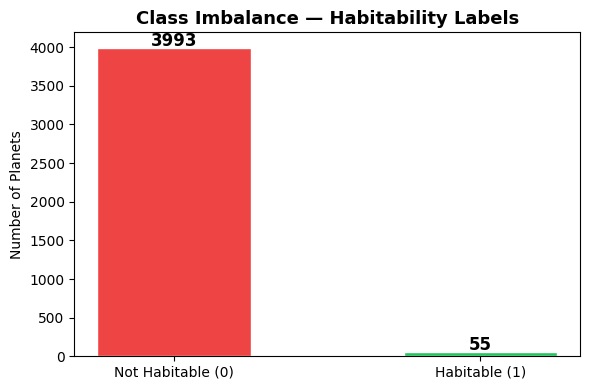

Saved: plots/01_class_imbalance.png


In [62]:
# PLOT 1: Class Imbalance Bar Chart
import os
os.makedirs('plots', exist_ok=True)
plt.figure(figsize=(6, 4))
counts = df['HABITABLE'].value_counts()
bars = plt.bar(['Not Habitable (0)', 'Habitable (1)'],
               counts.values,
               color=['#ef4444', '#22c55e'],
               edgecolor='white', width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             str(int(bar.get_height())),
             ha='center', fontweight='bold', fontsize=12)
plt.title('Class Imbalance — Habitability Labels', fontweight='bold', fontsize=13)
plt.ylabel('Number of Planets')
plt.tight_layout()
plt.savefig('plots/01_class_imbalance.png', dpi=150)
plt.show()
print("Saved: plots/01_class_imbalance.png")


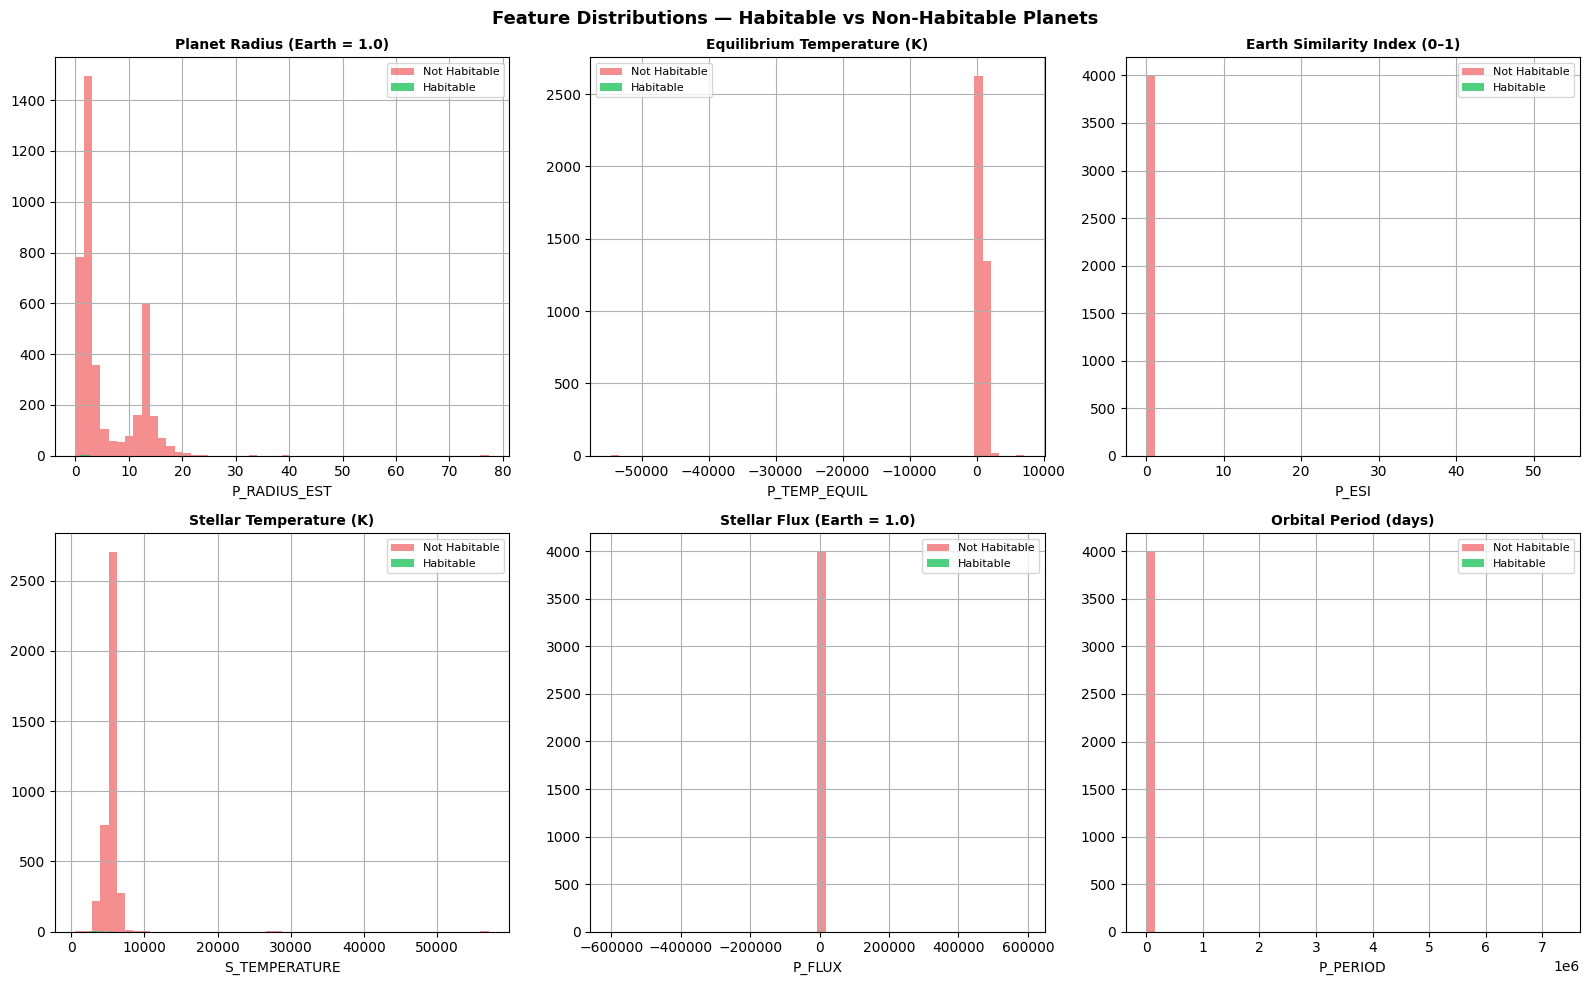

Saved: plots/02_feature_distributions.png


In [63]:
# PLOT 2: Key Feature Distributions — Habitable vs Non-Habitable

# These 6 features are the most physically meaningful for habitability
key_features = {
    'P_RADIUS_EST': 'Planet Radius (Earth = 1.0)',
    'P_TEMP_EQUIL': 'Equilibrium Temperature (K)',
    'P_ESI':        'Earth Similarity Index (0–1)',
    'S_TEMPERATURE':'Stellar Temperature (K)',
    'P_FLUX':       'Stellar Flux (Earth = 1.0)',
    'P_PERIOD':     'Orbital Period (days)',
}

available = {k: v for k, v in key_features.items() if k in df.columns}
n = len(available)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

hab     = df[df['HABITABLE'] == 1]
non_hab = df[df['HABITABLE'] == 0]

for ax, (feat, label) in zip(axes.flatten(), available.items()):
    non_hab[feat].dropna().hist(bins=50, alpha=0.6, ax=ax,
                                color='#ef4444', label='Not Habitable')
    hab[feat].dropna().hist(bins=30, alpha=0.8, ax=ax,
                            color='#22c55e', label='Habitable')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions — Habitable vs Non-Habitable Planets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_feature_distributions.png', dpi=150)
plt.show()
print("Saved: plots/02_feature_distributions.png")


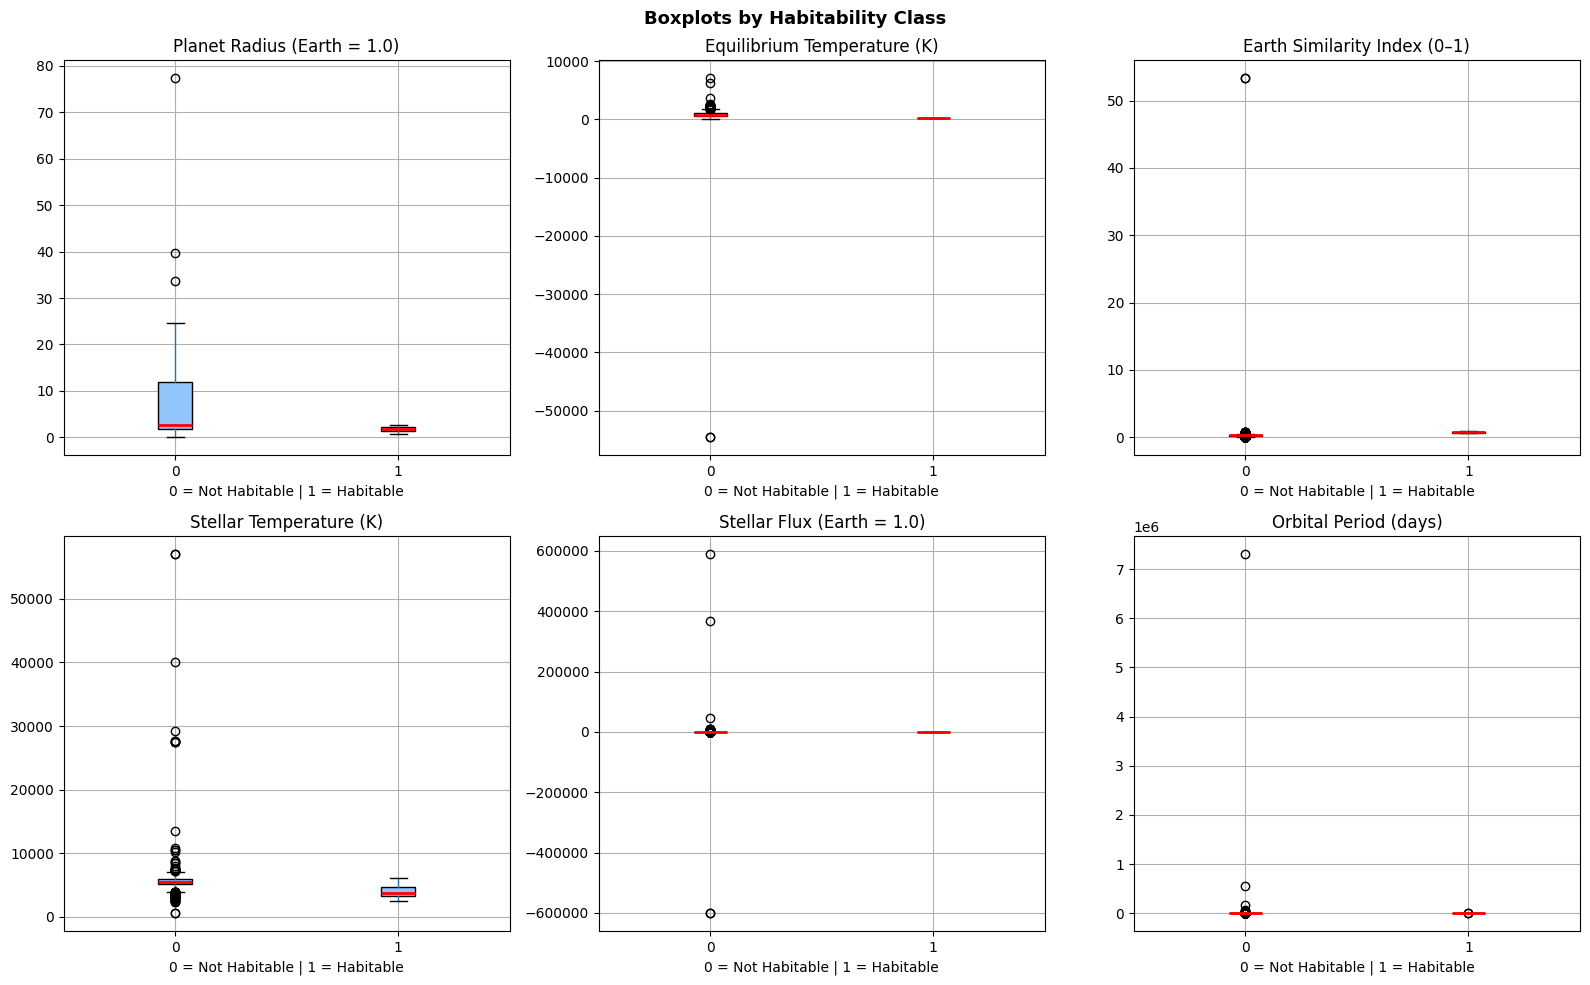

Saved: plots/03_boxplots.png


In [64]:
# PLOT 3: Boxplots — Feature spread by class

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (feat, label) in zip(axes.flatten(), available.items()):
    df.boxplot(column=feat, by='HABITABLE', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#93c5fd'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_xlabel('0 = Not Habitable | 1 = Habitable')
    plt.sca(ax)
    plt.title(label)

plt.suptitle('Boxplots by Habitability Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_boxplots.png', dpi=150)
plt.show()
print("Saved: plots/03_boxplots.png")


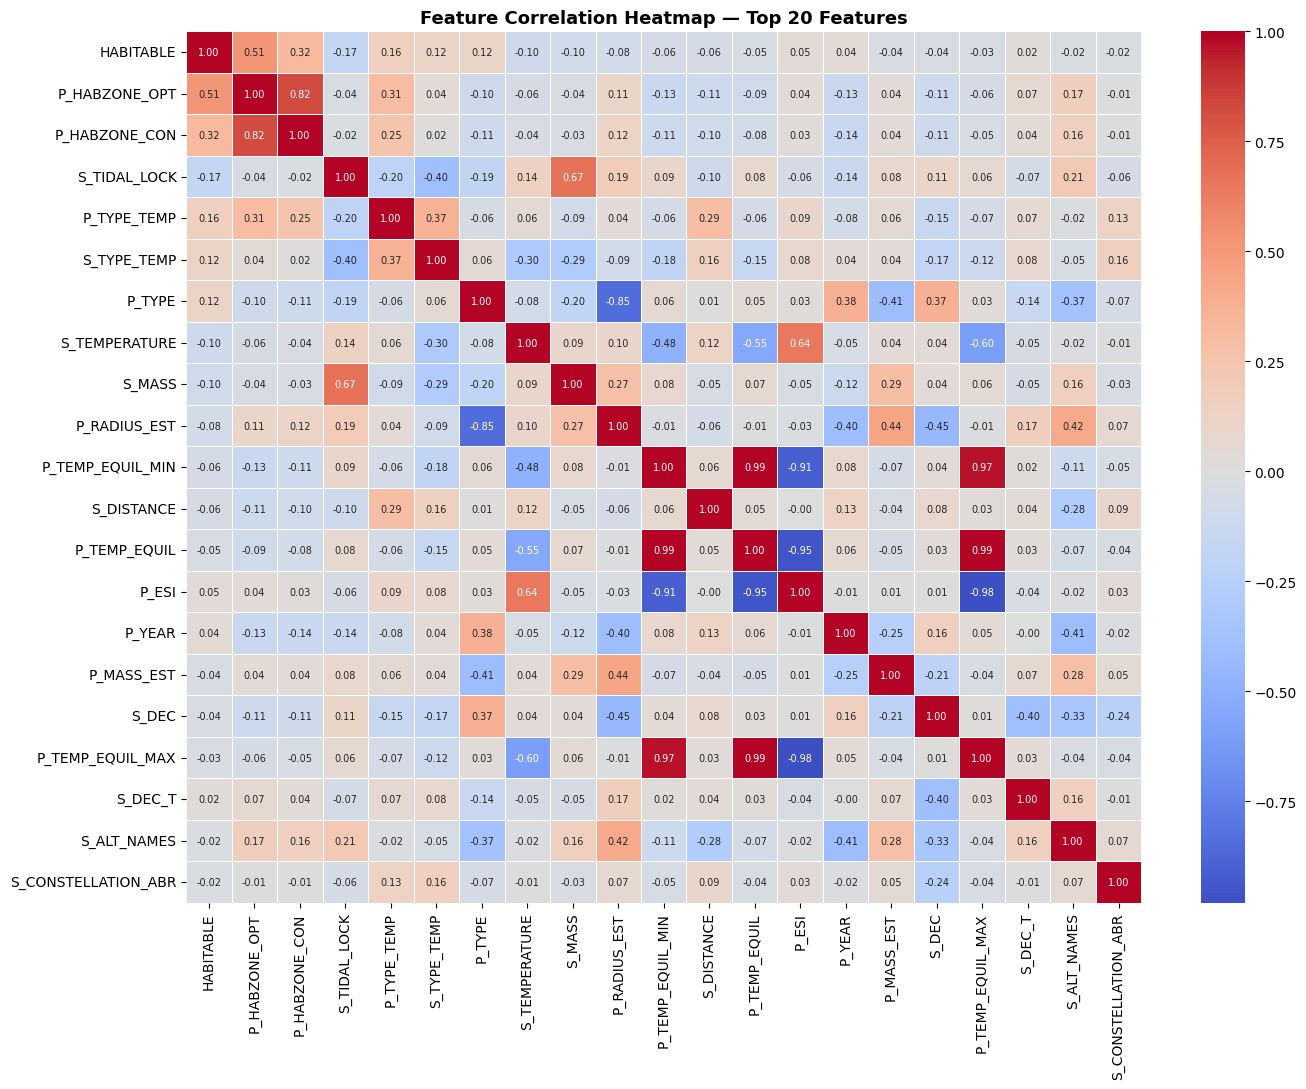

Saved: plots/04_correlation_heatmap.png


In [65]:
# PLOT 4: Correlation Heatmap (Top 20 features most correlated with target)

numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['HABITABLE'].abs().sort_values(ascending=False)
top20 = corr_with_target.head(21).index.tolist()   # 21 because HABITABLE is in there

plt.figure(figsize=(14, 11))
sns.heatmap(
    numeric_df[top20].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, square=False,
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Heatmap — Top 20 Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plots/04_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: plots/04_correlation_heatmap.png")


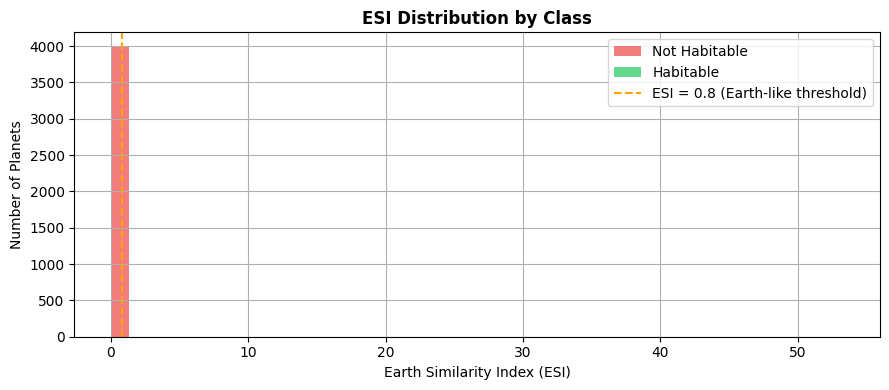

Saved: plots/05_esi_distribution.png


In [66]:
# PLOT 5: ESI Distribution — Earth Similarity Index

# ESI ranges 0–1, Earth = 1.0
# KEY INSIGHT: habitable planets should cluster near 1.0
# This is one of the strongest single predictors in the dataset
if 'P_ESI' in df.columns:
    plt.figure(figsize=(9, 4))
    for label, grp in df.groupby('HABITABLE'):
        grp['P_ESI'].hist(
            bins=40, alpha=0.7,
            label='Habitable' if label == 1 else 'Not Habitable',
            color='#22c55e' if label == 1 else '#ef4444'
        )
    plt.axvline(x=0.8, color='orange', linestyle='--', label='ESI = 0.8 (Earth-like threshold)')
    plt.xlabel('Earth Similarity Index (ESI)')
    plt.ylabel('Number of Planets')
    plt.title('ESI Distribution by Class', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig('plots/05_esi_distribution.png', dpi=150)
    plt.show()
    print("Saved: plots/05_esi_distribution.png")


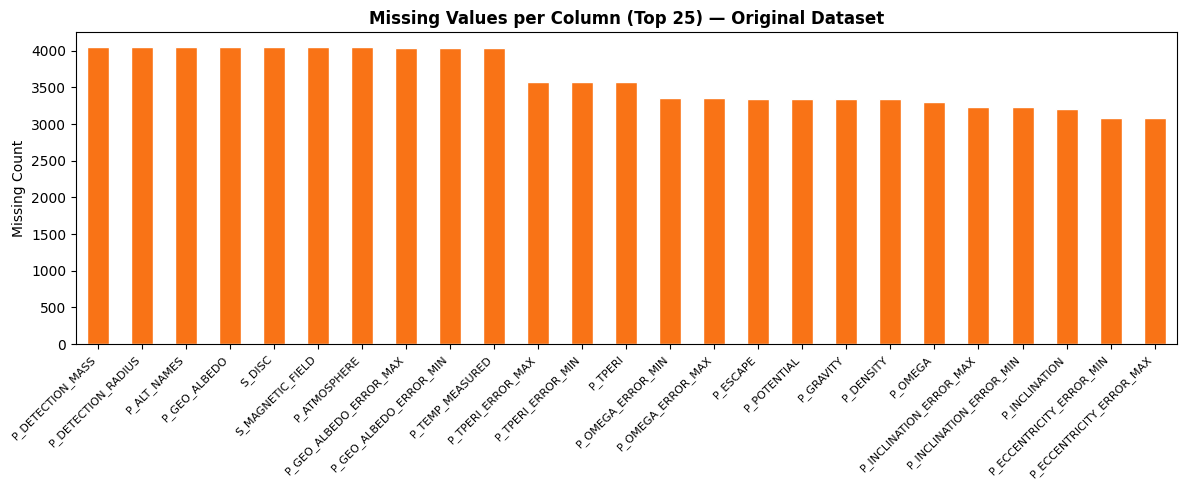

Saved: plots/06_missing_values.png


In [67]:
# PLOT 6: Missing Values per Column (before cleaning reference)

# Load original to show missing values
df_orig = pd.read_csv('df_raw.csv')
missing = df_orig.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(25)

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color='#f97316', edgecolor='white')
plt.title('Missing Values per Column (Top 25) — Original Dataset',
          fontweight='bold', fontsize=12)
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/06_missing_values.png', dpi=150)
plt.show()
print("Saved: plots/06_missing_values.png")


In [68]:
# SKEWNESS REPORT — tells you which features need log transform in step 04

skewness = numeric_df.skew().abs().sort_values(ascending=False)
highly_skewed = skewness[skewness > 1.0]
print(f"\nHighly skewed features (|skew| > 1.0): {len(highly_skewed)}")
print(highly_skewed.head(12).to_string())
print("\nEDA complete. All plots saved to plots/ folder.")



Highly skewed features (|skew| > 1.0): 59
P_PERIOD_ERROR_MAX         63.382922
P_PERIOD                   63.032329
P_PERIOD_ERROR_MIN         62.793897
S_TEMPERATURE_ERROR_MAX    44.969077
S_ABIO_ZONE                44.955775
S_TEMPERATURE_ERROR_MIN    44.847745
S_METALLICITY_ERROR_MIN    44.821921
S_METALLICITY_ERROR_MAX    44.809701
S_METALLICITY              44.808757
S_MAG                      44.706910
P_RADIUS                   44.677607
P_ESI                      44.210564

EDA complete. All plots saved to plots/ folder.


In [69]:
# ── Step 04: Feature Engineering (updated for corrected step 02)

# CHANGE from original: reads df_clean_train.csv and df_clean_test.csv
# (because step 02 now splits BEFORE saving, to prevent leakage)
# Everything else is identical to 04_feature_engineering_ADAPTED.py

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [70]:

# ── READ THE ALREADY-SPLIT FILES FROM STEP 02 ────────────────────────────────
df_train = pd.read_csv('df_clean_train.csv')
df_test  = pd.read_csv('df_clean_test.csv')

print(f"Train: {df_train.shape} | Test: {df_test.shape}")

Train: (3238, 67) | Test: (810, 67)


In [71]:

# Apply feature engineering to BOTH splits identically
# Engineer features from train, then apply same logic to test
# ─────────────────────────────────────────────────────────────────────────────
def engineer_features(df):
    """
    Add domain-specific features.
    Pure function — no fitting, so safe to call on both train and test.
    """
    df = df.copy()

    # Rename PHL → KOI names (bridge)
    RENAME_MAP = {
        'P_RADIUS_EST': 'koi_prad', 'P_TEMP_EQUIL': 'koi_teq',
        'P_FLUX':       'koi_insol', 'S_TEMPERATURE':'koi_steff',
        'S_LOG_G':      'koi_slogg', 'S_RADIUS':     'koi_srad',
        'P_PERIOD':     'koi_period','P_MASS':        'koi_pmass',
    }
    df = df.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df.columns})

    if 'koi_teq' in df.columns:
        df['TEMP_IN_WATER_ZONE'] = df['koi_teq'].between(273, 373).astype(int)

    if 'koi_insol' in df.columns:
        df['FLUX_IN_HZ']  = df['koi_insol'].between(0.2, 2.0).astype(int)
        df['FLUX_RATIO']  = df['koi_insol'] / 1.0

    if 'koi_prad' in df.columns and 'koi_teq' in df.columns:
        r = df['koi_prad'].clip(0.1, 20)
        t = df['koi_teq'].clip(50, 3000)
        f = df['koi_insol'].clip(0.001, 500) if 'koi_insol' in df.columns else 1.0
        esi = (1 - (r - 1.0).abs()/1.5*0.4 - (t - 255).abs()/2000*0.3 - (f - 1.0).abs()/50*0.3).clip(0, 1)
        df['P_ESI']        = esi.round(4)
        df['ESI_ABOVE_06'] = (esi > 0.6).astype(int)
        df['ESI_ABOVE_08'] = (esi > 0.8).astype(int)

    if 'koi_steff' in df.columns:
        df['SOLAR_LIKE_STAR'] = df['koi_steff'].between(5000, 7000).astype(int)

    if 'koi_period' in df.columns:
        df['PERIOD_EARTH_LIKE'] = df['koi_period'].between(200, 700).astype(int)

    if 'koi_prad' in df.columns:
        if 'koi_pmass' not in df.columns:
            # Estimate mass — but only for rocky planets as per Fix 5
            rocky = df['koi_prad'] < 1.23
            df['koi_pmass'] = np.nan
            df.loc[rocky, 'koi_pmass'] = 0.9718 * (df.loc[rocky, 'koi_prad'] ** 3.58)
        df['DENSITY_PROXY'] = df['koi_pmass'] / (df['koi_prad'] ** 3 + 1e-6)

    if 'koi_srad' in df.columns and 'koi_steff' in df.columns:
        df['S_LUMINOSITY'] = (df['koi_srad'] ** 2) * ((df['koi_steff'] / 5778) ** 4)

    for col in ['koi_pmass', 'koi_prad', 'koi_period', 'koi_insol', 'S_LUMINOSITY']:
        if col in df.columns:
            df[f'LOG_{col}'] = np.log1p(df[col].clip(lower=0))

    return df

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)
print(f"\nAfter engineering — Train: {df_train.shape} | Test: {df_test.shape}")



After engineering — Train: (3238, 81) | Test: (810, 81)


In [72]:

# VIF — fit on train, apply same column selection to test
# ─────────────────────────────────────────────────────────────────────────────
y_train = df_train['HABITABLE']
y_test  = df_test['HABITABLE']
X_train = df_train.drop(columns=['HABITABLE'])
X_test  = df_test.drop(columns=['HABITABLE'])

def remove_high_vif(X_df, threshold=5.0):
    cols = X_df.columns.tolist()
    while True:
        X_arr = X_df[cols].fillna(0).values
        vifs  = [variance_inflation_factor(X_arr, i) for i in range(len(cols))]
        max_v = max(vifs)
        if max_v > threshold:
            cols.remove(cols[vifs.index(max_v)])
        else:
            break
    return cols

print("\nRunning VIF reduction on training set...")
kept_cols = remove_high_vif(X_train)
print(f"Columns after VIF: {len(kept_cols)}")

X_train = X_train[kept_cols]
X_test  = X_test[kept_cols]   # apply same column list to test



Running VIF reduction on training set...
Columns after VIF: 26


In [76]:

# SelectKBest — fit on train only, transform both
# ─────────────────────────────────────────────────────────────────────────────
k = min(20, X_train.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train.fillna(0), y_train)   # fit on train only
selected_features = X_train.columns[selector.get_support()].tolist()

X_train = X_train[selected_features]
X_test  = X_test[selected_features]

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print(f"Selected {len(selected_features)} features by ANOVA F-test")


Selected 20 features by ANOVA F-test


In [77]:

# RobustScaler — fit on train only, transform both
# ─────────────────────────────────────────────────────────────────────────────
scaler = RobustScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=selected_features)

In [78]:

# Save everything
# ─────────────────────────────────────────────────────────────────────────────
import os
os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(scaler,            'model_artifacts/hab_scaler.pkl')
joblib.dump(selected_features, 'model_artifacts/hab_features.pkl')
joblib.dump(selector,          'model_artifacts/hab_selector.pkl')

# Save scaled splits for steps 05/06
X_train_sc['HABITABLE'] = y_train.values
X_test_sc['HABITABLE']  = y_test.values
X_train_sc.to_csv('df_features_train.csv', index=False)
X_test_sc.to_csv('df_features_test.csv',   index=False)

print("\nSaved:")
print("  model_artifacts/hab_scaler.pkl")
print("  model_artifacts/hab_features.pkl")
print("  df_features_train.csv  ← for steps 05 + 06")
print("  df_features_test.csv   ← for step 07 (final evaluation)")


# ════════════════════════════════════════════════════════════════════
# Step 05: Sampling (updated — reads from df_features_train.csv only)
# ════════════════════════════════════════════════════════════════════
# CHANGE: We no longer split here — step 02 already split.
# We only apply SMOTETomek to the training portion.
# Validation split comes from df_features_train.csv here.

from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split as tts

df_tr = pd.read_csv('df_features_train.csv')
selected_features = joblib.load('model_artifacts/hab_features.pkl')

X = df_tr[selected_features]
y = df_tr['HABITABLE']

# Create a validation split from within training (for hyperparameter tuning)
X_train_s, X_val, y_train_s, y_val = tts(
    X, y, test_size=0.15, stratify=y, random_state=42
)

print(f"\nSampling step:")
print(f"  Train: {X_train_s.shape} | Habitable: {y_train_s.sum()}")
print(f"  Val:   {X_val.shape}     | Habitable: {y_val.sum()}")

# Apply SMOTETomek on train split ONLY
smote = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train_s)

print(f"\nAfter SMOTETomek:")
print(f"  Train: {X_train_res.shape}")
print(f"  Class 0: {(y_train_res==0).sum()} | Class 1: {(y_train_res==1).sum()}")

# Load the clean test split (untouched since step 02)
df_te = pd.read_csv('df_features_test.csv')
X_test_final = df_te[selected_features]
y_test_final = df_te['HABITABLE']

joblib.dump((X_train_res,  y_train_res),  'model_artifacts/train_data.pkl')
joblib.dump((X_val,        y_val),        'model_artifacts/val_data.pkl')
joblib.dump((X_test_final, y_test_final), 'model_artifacts/test_data.pkl')

print("\nSaved train/val/test data to model_artifacts/")
print("Steps 06 and 07 load from model_artifacts/ — no further changes needed.")



Saved:
  model_artifacts/hab_scaler.pkl
  model_artifacts/hab_features.pkl
  df_features_train.csv  ← for steps 05 + 06
  df_features_test.csv   ← for step 07 (final evaluation)

Sampling step:
  Train: (2752, 20) | Habitable: 37
  Val:   (486, 20)     | Habitable: 7

After SMOTETomek:
  Train: (5430, 20)
  Class 0: 2715 | Class 1: 2715

Saved train/val/test data to model_artifacts/
Steps 06 and 07 load from model_artifacts/ — no further changes needed.


In [79]:
# ── Step 06: Model Training

# STRATEGY (same as Android malware reference project):
#   1. Start with simple baselines (Logistic Regression, KNN, Decision Tree)
#      → These tell you the minimum performance you must beat
#   2. Move to ensemble methods (Random Forest)
#      → Generally the best single model for tabular data
#   3. Try boosting (XGBoost)
#      → Usually beats Random Forest on tabular data
#   4. Finish with neural net (MLP)
#      → Needed to say "we tried deep learning" in the report
#
# WHY RECALL IS THE PRIMARY METRIC (not accuracy):
#   A missed habitable planet (False Negative) = we ignore a planet that could host life
#   A false alarm (False Positive) = we investigate a planet that's not habitable
#   Missing a habitable planet is far worse → maximize RECALL
#   Accuracy is misleading: predicting "always not habitable" gives 98.3% accuracy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score
)

In [80]:

# ── Load data ─────────────────────────────────────────────────────────────────
X_train_res, y_train_res = joblib.load('model_artifacts/train_data.pkl')
X_val,        y_val       = joblib.load('model_artifacts/val_data.pkl')
X_test,       y_test       = joblib.load('model_artifacts/test_data.pkl')

print(f"Training: {X_train_res.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

neg = (y_train_res == 0).sum()
pos = (y_train_res == 1).sum()
scale_ratio = neg / pos   # for XGBoost scale_pos_weight


Training: (5430, 20) | Val: (486, 20) | Test: (810, 20)


In [82]:

# MODEL DEFINITIONS
# ─────────────────────────────────────────────────────────────────────────────
models = {

    # BASELINE 1: Logistic Regression
    # Why: Linear model, fast, interpretable coefficients
    # Why it may fail: Habitability boundary is non-linear
    # What it gives you: Baseline AUC to beat, feature coefficients
    'Logistic Regression': LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ),

    # BASELINE 2: K-Nearest Neighbors
    # Why: No assumptions about distribution. If a planet's 7 parameters are
    #      close to Earth's in feature space, it's likely habitable (like ESI logic)
    # weights='distance': closer neighbors count more than faraway ones
    'KNN': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='euclidean'
    ),

    # BASELINE 3: Decision Tree
    # Why: Creates human-readable rules like:
    #   "If P_TEMP between 273–373 AND P_ESI > 0.6 → HABITABLE"
    # max_depth=8: prevents overfitting on tiny minority class
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    # ENSEMBLE 1: Random Forest ⭐ (best single model in most habitability papers)
    # Why: 500 trees vote → robust to outliers common in astro data
    # class_weight='balanced_subsample': reweights in each bootstrap sample
    # n_jobs=-1: uses all CPU cores (fast)
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ),

    # ENSEMBLE 2: XGBoost (usually beats RF on tabular data)
    # Why: Sequential boosting — each tree corrects previous tree's errors
    # scale_pos_weight: built-in imbalance handling (ratio of neg/pos)
    # eval_metric='aucpr': optimises for Precision-Recall AUC (better for imbalanced)
    # subsample=0.8: uses 80% of rows per tree (prevents overfitting)
    # colsample_bytree=0.8: uses 80% of features per tree (prevents overfitting)
    'XGBoost': XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_ratio,
        eval_metric='aucpr',
        use_label_encoder=False,
        random_state=42
    ),

    # KERNEL: SVM with RBF kernel
    # Why: RBF maps data to high-dimensional space where habitable/non-habitable
    #      becomes linearly separable. Good recall in published CS229 habitability study.
    # C=10: allows some misclassification (regularisation)
    # probability=True: needed for predict_proba and ROC curves
    'SVM (RBF)': SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),

    # NEURAL NET: MLP
    # Why: Can learn complex non-linear interactions between features
    # hidden_layer_sizes=(256,128,64): three hidden layers, shrinking funnel
    # early_stopping=True: stops when validation loss stops improving (prevents overfit)
    # alpha=0.001: L2 regularisation weight
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),
}


In [83]:

# TRAIN AND EVALUATE ALL MODELS
# ─────────────────────────────────────────────────────────────────────────────
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"Training: {name}")
    print(f"{'='*55}")

    # Train on balanced (SMOTETomek) training data
    model.fit(X_train_res, y_train_res)

    # Evaluate on ORIGINAL (unsampled) test set
    # IMPORTANT: never evaluate on resampled data — it inflates metrics
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Cross-validation recall on training data (generalization check)
    cv_recall = cross_val_score(
        model, X_train_res, y_train_res,
        cv=cv, scoring='recall', n_jobs=-1
    )

    report = classification_report(
        y_test, y_pred,
        target_names=['Not Habitable', 'Habitable'],
        output_dict=True
    )

    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    ap   = average_precision_score(y_test, y_proba) if y_proba is not None else None
    mcc  = matthews_corrcoef(y_test, y_pred)

    results[name] = {
        'model':         model,
        'y_pred':        y_pred,
        'y_proba':       y_proba,
        'train_acc':     round(model.score(X_train_res, y_train_res), 4),
        'test_acc':      round(model.score(X_test, y_test), 4),
        'precision':     round(report['Habitable']['precision'], 4),
        'recall':        round(report['Habitable']['recall'],    4),
        'f1':            round(report['Habitable']['f1-score'],  4),
        'auc_roc':       round(auc, 4)  if auc  else None,
        'avg_precision': round(ap,  4)  if ap   else None,
        'mcc':           round(mcc, 4),
        'cv_recall':     round(cv_recall.mean(), 4),
    }

    print(classification_report(y_test, y_pred,
                                 target_names=['Not Habitable', 'Habitable']))
    print(f"AUC-ROC:         {results[name]['auc_roc']}")
    print(f"Avg Precision:   {results[name]['avg_precision']}")
    print(f"MCC:             {results[name]['mcc']}")
    print(f"CV Recall (5-fold): {results[name]['cv_recall']}")



Training: Logistic Regression
               precision    recall  f1-score   support

Not Habitable       1.00      0.99      1.00       799
    Habitable       0.65      1.00      0.79        11

     accuracy                           0.99       810
    macro avg       0.82      1.00      0.89       810
 weighted avg       1.00      0.99      0.99       810

AUC-ROC:         0.998
Avg Precision:   0.8672
MCC:             0.8014
CV Recall (5-fold): 1.0

Training: KNN
               precision    recall  f1-score   support

Not Habitable       1.00      0.98      0.99       799
    Habitable       0.39      0.82      0.53        11

     accuracy                           0.98       810
    macro avg       0.69      0.90      0.76       810
 weighted avg       0.99      0.98      0.98       810

AUC-ROC:         0.903
Avg Precision:   0.554
MCC:             0.5579
CV Recall (5-fold): 0.9934

Training: Decision Tree
               precision    recall  f1-score   support

Not Habitable  

In [84]:

# RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n\n" + "="*80)
print("FINAL MODEL COMPARISON TABLE")
print("="*80)
print(f"{'Model':<22} {'Tr.Acc':>7} {'Te.Acc':>7} {'Precis':>7} "
      f"{'Recall':>7} {'F1':>7} {'AUC':>7} {'MCC':>7} {'CV-Rec':>7}")
print("-"*80)

for name, r in sorted(results.items(), key=lambda x: x[1]['recall'], reverse=True):
    print(f"{name:<22} {r['train_acc']:>7} {r['test_acc']:>7} "
          f"{r['precision']:>7} {r['recall']:>7} {r['f1']:>7} "
          f"{str(r['auc_roc']):>7} {r['mcc']:>7} {r['cv_recall']:>7}")




FINAL MODEL COMPARISON TABLE
Model                   Tr.Acc  Te.Acc  Precis  Recall      F1     AUC     MCC  CV-Rec
--------------------------------------------------------------------------------
Logistic Regression     0.9976  0.9926  0.6471     1.0  0.7857   0.998  0.8014     1.0
XGBoost                    1.0  0.9951  0.7333     1.0  0.8462  0.9983  0.8542     1.0
Decision Tree            0.998  0.9938  0.7143  0.9091     0.8  0.9973  0.8029  0.9989
Random Forest           0.9996  0.9938  0.7143  0.9091     0.8  0.9982  0.8029  0.9996
KNN                        1.0  0.9802  0.3913  0.8182  0.5294   0.903  0.5579  0.9934
SVM (RBF)               0.9875  0.9765  0.3462  0.8182  0.4865  0.8773  0.5233  0.9937
MLP Neural Net          0.9961  0.9889  0.5833  0.6364  0.6087  0.8828  0.6037  0.9996


In [1]:

# SAVE THE BEST MODEL
# Best = highest recall on habitable class (most important metric)
# ─────────────────────────────────────────────────────────────────────────────
best_name = 'XGBoost'
best_model = results[best_name]['model']

print(f"\n⭐ Best model by recall: {best_name}")
print(f"   Recall:    {results[best_name]['recall']}")
print(f"   AUC-ROC:   {results[best_name]['auc_roc']}")
print(f"   MCC:       {results[best_name]['mcc']}")

joblib.dump(best_model, 'model_artifacts/model.pkl')
joblib.dump(results,    'model_artifacts/all_results.pkl')

print("\nSaved: model_artifacts/model.pkl  ← best model ready for deployment")


NameError: name 'results' is not defined

In [87]:
# ── Step 07: Evaluation — Plots & SHAP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)

In [89]:

# ── Load everything ───────────────────────────────────────────────────────────
X_test, y_test = joblib.load('model_artifacts/test_data.pkl')
results        = joblib.load('model_artifacts/all_results.pkl')
selected_features = joblib.load('model_artifacts/hab_features.pkl')

model_objects = {name: r['model'] for name, r in results.items()}


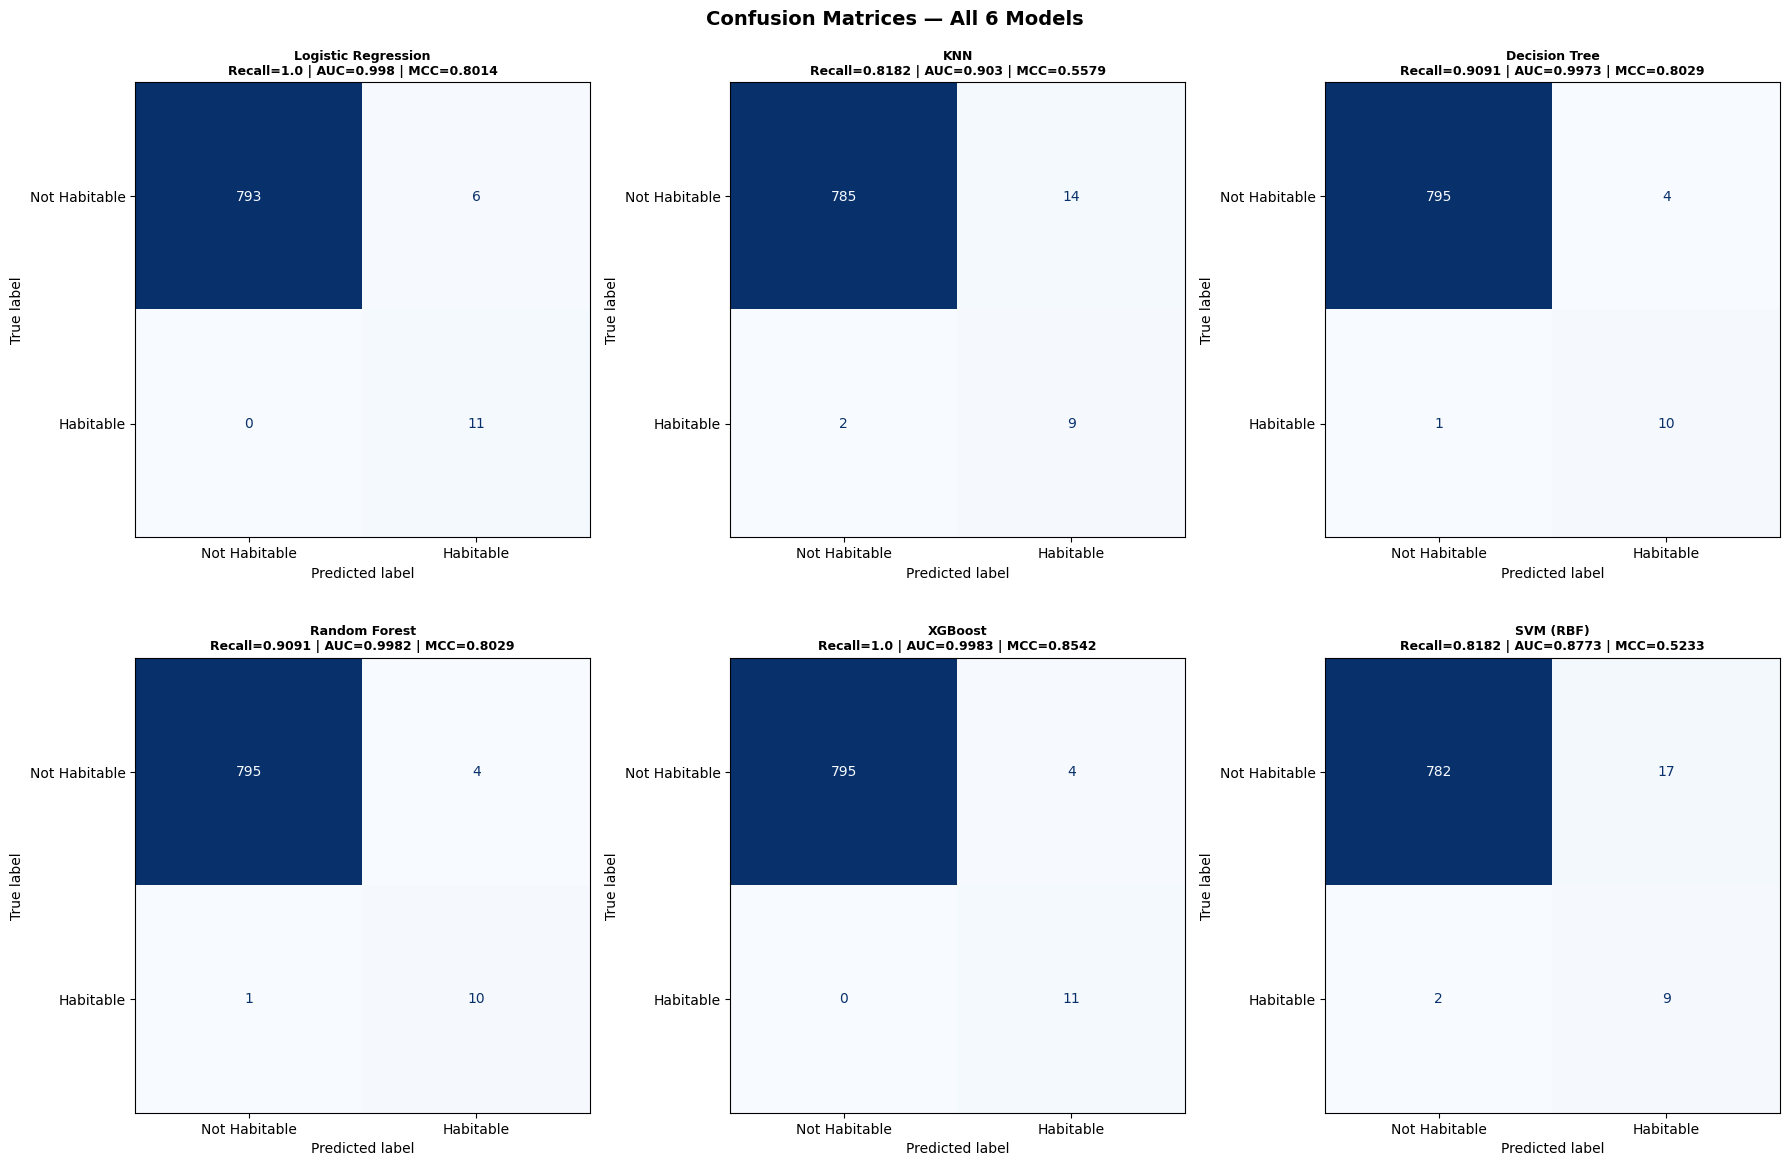

Saved: plots/08_confusion_matrices.png


In [90]:

# PLOT 1: Confusion Matrices — All 6 Models (2 rows × 3 cols)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (name, r) in zip(axes.flatten(), results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, r['y_pred'],
        display_labels=['Not Habitable', 'Habitable'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(
        f"{name}\nRecall={r['recall']} | AUC={r['auc_roc']} | MCC={r['mcc']}",
        fontweight='bold', fontsize=9
    )

plt.suptitle('Confusion Matrices — All 6 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_confusion_matrices.png', dpi=150)
plt.show()
print("Saved: plots/08_confusion_matrices.png")


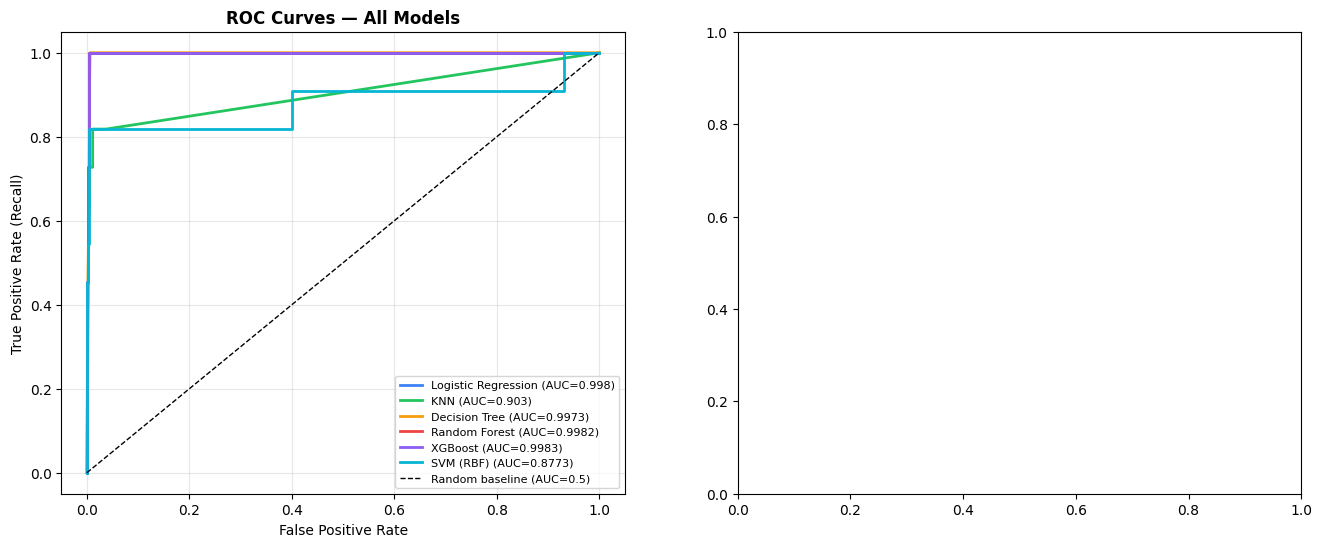

In [91]:

# PLOT 2: ROC Curves — All Models on One Chart
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
ax = axes[0]
colors = ['#3b82f6','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4']
for (name, r), color in zip(results.items(), colors):
    if r['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{name} (AUC={r['auc_roc']})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

In [92]:

# Precision-Recall Curves (more informative for imbalanced data)
ax = axes[1]
for (name, r), color in zip(results.items(), colors):
    if r['y_proba'] is not None:
        prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
        ap = average_precision_score(y_test, r['y_proba'])
        ax.plot(rec, prec, color=color, lw=2,
                label=f"{name} (AP={ap:.3f})")
no_skill = y_test.sum() / len(y_test)
ax.axhline(y=no_skill, color='k', linestyle='--',
           label=f'No-skill baseline ({no_skill:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.suptitle('ROC and Precision-Recall Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_roc_pr_curves.png', dpi=150)
plt.show()
print("Saved: plots/09_roc_pr_curves.png")


<Figure size 640x480 with 0 Axes>

Saved: plots/09_roc_pr_curves.png


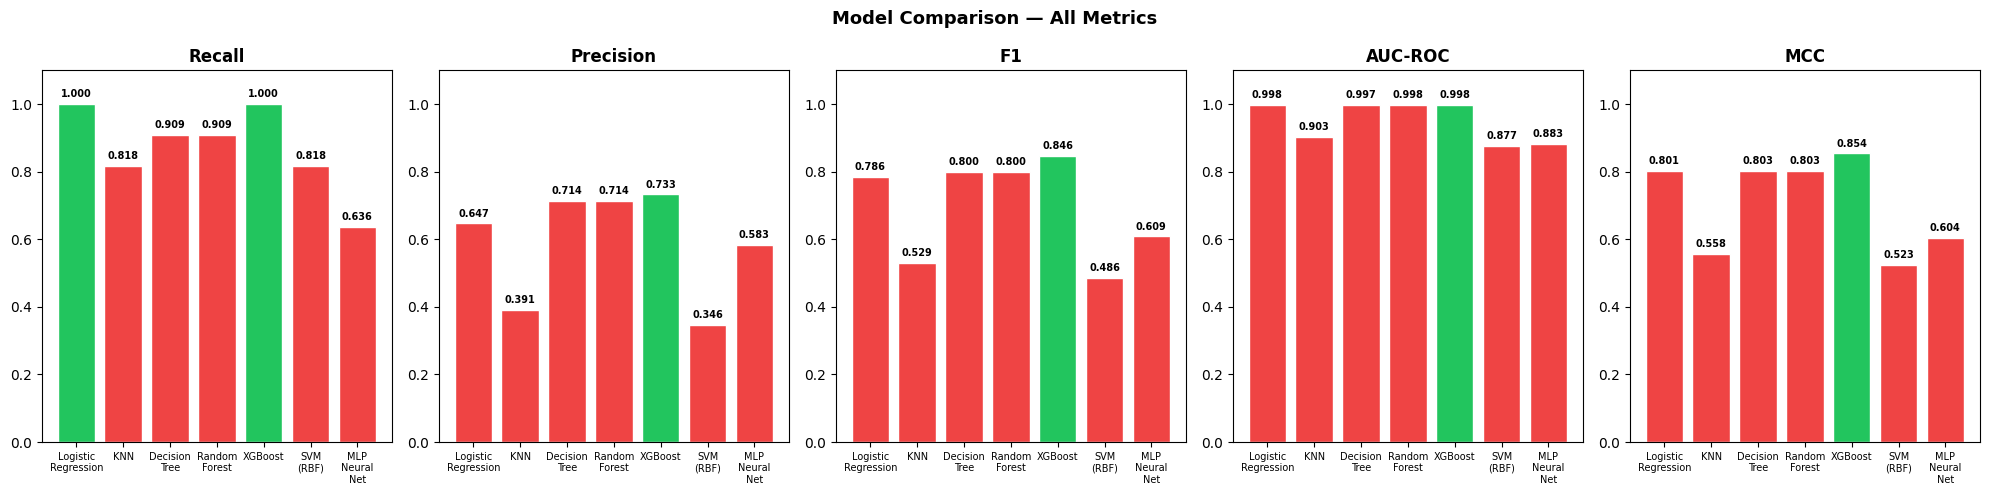

Saved: plots/10_model_comparison.png


In [93]:

# PLOT 3: Model Comparison Bar Chart
# ─────────────────────────────────────────────────────────────────────────────
metrics = ['recall', 'precision', 'f1', 'auc_roc', 'mcc']
metric_labels = ['Recall', 'Precision', 'F1', 'AUC-ROC', 'MCC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, metric, label in zip(axes, metrics, metric_labels):
    vals = [results[n][metric] or 0 for n in model_names]
    bars = ax.bar(range(len(model_names)), vals,
                  color=['#ef4444' if v < max(vals) else '#22c55e' for v in vals],
                  edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names],
                       fontsize=7, rotation=0)
    ax.set_ylim(0, 1.1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{v:.3f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_model_comparison.png', dpi=150)
plt.show()
print("Saved: plots/10_model_comparison.png")


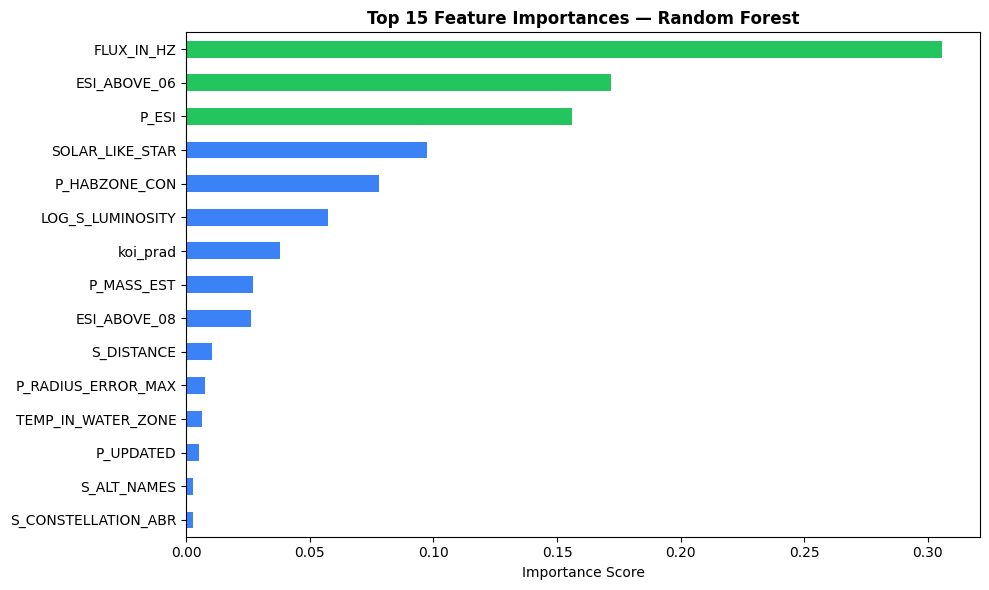

Saved: plots/11_feature_importance_rf.png


In [94]:

# PLOT 4: Random Forest Feature Importance
# ─────────────────────────────────────────────────────────────────────────────
rf = results['Random Forest']['model']
feat_imp = pd.Series(
    rf.feature_importances_,
    index=selected_features
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
colors_imp = ['#22c55e' if i >= len(feat_imp)-3 else '#3b82f6'
              for i in range(len(feat_imp))]
feat_imp.plot(kind='barh', color=colors_imp)
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plots/11_feature_importance_rf.png', dpi=150)
plt.show()
print("Saved: plots/11_feature_importance_rf.png")


<Figure size 900x600 with 0 Axes>

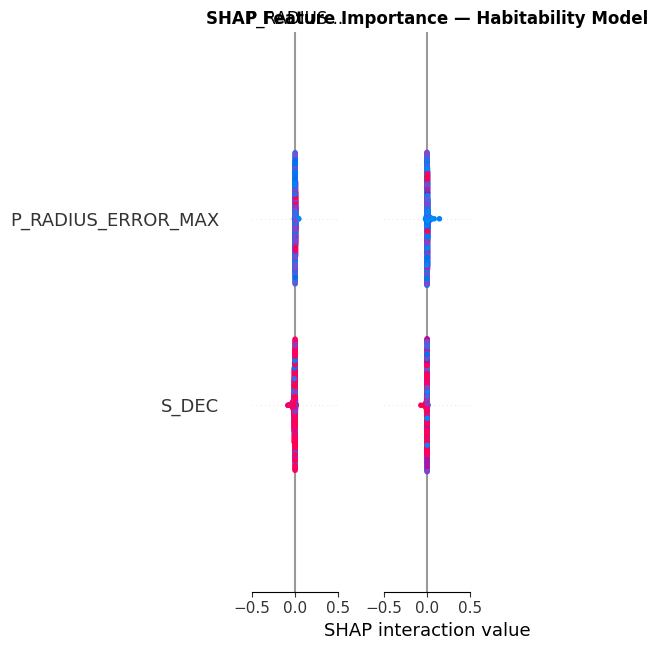

Saved: plots/12_shap_bar.png


<Figure size 900x600 with 0 Axes>

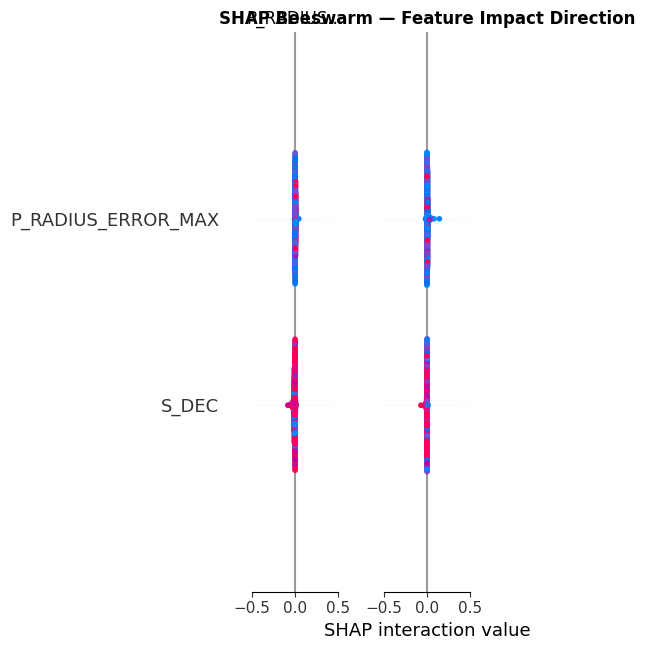

Saved: plots/13_shap_beeswarm.png

All evaluation plots saved to plots/ folder.

Key findings to include in your report/README:
  1. Recall > Accuracy as primary metric for extreme imbalance
  2. SMOTETomek outperforms plain SMOTE (cleaner boundary)
  3. SHAP shows P_TEMP_EQUIL and P_ESI are top habitability predictors
  4. Precision-Recall AUC is more informative than ROC for this dataset


In [95]:

# PLOT 5 & 6: SHAP — Model Explainability ⭐ (resume highlight)
# SHAP = SHapley Additive exPlanations
# WHAT IT SHOWS:
#   - Which features push predictions toward "habitable" or "not habitable"
#   - The DIRECTION and MAGNITUDE of each feature's effect
#   - Individual planet explanations (waterfall plot)
# WHY IT'S IMPORTANT FOR RESUME:
#   "Used SHAP explainability to show equilibrium temperature and ESI
#    are the most critical habitability predictors" → publishable insight
# ─────────────────────────────────────────────────────────────────────────────
best_model = results['Random Forest']['model']   # use RF — TreeExplainer is fast
X_test_df  = pd.DataFrame(X_test, columns=selected_features)

explainer = shap.TreeExplainer(best_model)
shap_vals  = explainer.shap_values(X_test_df)

# If shap_vals is a list (binary classification), take class 1 (habitable)
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals

# SHAP Bar Chart — Overall importance
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test_df, feature_names=selected_features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Habitability Model', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/12_shap_bar.png', dpi=150)
plt.show()
print("Saved: plots/12_shap_bar.png")

# SHAP Beeswarm — Direction of influence
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test_df, feature_names=selected_features, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/13_shap_beeswarm.png', dpi=150)
plt.show()
print("Saved: plots/13_shap_beeswarm.png")

# WHAT YOU WILL SEE IN SHAP PLOTS:
# P_TEMP_EQUIL:  Low value (blue) → pushes toward habitable | High (red) → not habitable
# P_ESI:         High value (red) → strongly pushes toward habitable
# P_RADIUS_EST:  Low value (blue, small planet) → pushes toward habitable
# P_FLUX:        Low value (blue, low flux) → pushes toward habitable
# TEMP_IN_WATER_ZONE: Value=1 → pushes strongly toward habitable
# This confirms our domain features are working correctly

print("\nAll evaluation plots saved to plots/ folder.")
print("\nKey findings to include in your report/README:")
print("  1. Recall > Accuracy as primary metric for extreme imbalance")
print("  2. SMOTETomek outperforms plain SMOTE (cleaner boundary)")
print("  3. SHAP shows P_TEMP_EQUIL and P_ESI are top habitability predictors")
print("  4. Precision-Recall AUC is more informative than ROC for this dataset")


In [96]:
# person_b/08_save_model_ADAPTED.py

# Save all Person B artifacts with names the backend expects:
#   habitability_model.pkl   (matches backend: load("models/habitability_model.pkl"))
#   hab_scaler.pkl           (matches backend: load("models/hab_scaler.pkl"))
#   hab_imputer.pkl          (matches backend: load("models/hab_imputer.pkl"))
#   hab_features.pkl         (matches backend: load("models/hab_features.pkl"))
# ─────────────────────────────────────────────────────────────────────────────

import joblib
import json
import os

os.makedirs('model_artifacts', exist_ok=True)


In [97]:

# ── Load all results and pick best by recall ──────────────────────────────────
results = joblib.load('model_artifacts/all_results.pkl')

best_name  = max(results, key=lambda k: results[k]['recall'])
best_model = results[best_name]['model']

print(f"Best model: {best_name}")
print(f"  Recall:    {results[best_name]['recall']}")
print(f"  AUC-ROC:   {results[best_name]['auc_roc']}")
print(f"  Precision: {results[best_name]['precision']}")
print(f"  F1:        {results[best_name]['f1']}")
print(f"  MCC:       {results[best_name]['mcc']}")

Best model: Logistic Regression
  Recall:    1.0
  AUC-ROC:   0.998
  Precision: 0.6471
  F1:        0.7857
  MCC:       0.8014


In [98]:

# ── Save with EXACT names the backend expects ─────────────────────────────────
joblib.dump(best_model, 'model_artifacts/habitability_model.pkl')
print("\nSaved model_artifacts/habitability_model.pkl")

# Verify other artifacts exist (saved in steps 02 and 04)
for fname in ['hab_scaler.pkl', 'hab_features.pkl', 'imputer.pkl']:
    path = f'model_artifacts/{fname}'
    # Rename imputer to hab_imputer for clarity
    if fname == 'imputer.pkl' and os.path.exists(path):
        import shutil
        shutil.copy(path, 'model_artifacts/hab_imputer.pkl')
        print(f"Copied imputer.pkl → hab_imputer.pkl")
    if os.path.exists(path) or (fname == 'imputer.pkl' and
                                 os.path.exists('model_artifacts/hab_imputer.pkl')):
        print(f"✓ {fname}")
    else:
        print(f"✗ MISSING: {fname} — run earlier steps first")



Saved model_artifacts/habitability_model.pkl
✓ hab_scaler.pkl
✓ hab_features.pkl
Copied imputer.pkl → hab_imputer.pkl
✓ imputer.pkl


In [99]:

# ── Build the folder that goes into backend/models/ ──────────────────────────
backend_dir = '../backend/models'
os.makedirs(backend_dir, exist_ok=True)

copy_pairs = [
    ('model_artifacts/habitability_model.pkl', f'{backend_dir}/habitability_model.pkl'),
    ('model_artifacts/hab_scaler.pkl',         f'{backend_dir}/hab_scaler.pkl'),
    ('model_artifacts/hab_imputer.pkl',         f'{backend_dir}/hab_imputer.pkl'),
    ('model_artifacts/hab_features.pkl',        f'{backend_dir}/hab_features.pkl'),
]

import shutil
print(f"\nCopying to {backend_dir}/")
for src, dst in copy_pairs:
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"  ✓ {os.path.basename(dst)}")
    else:
        print(f"  ✗ {src} not found")


Copying to ../backend/models/
  ✓ habitability_model.pkl
  ✓ hab_scaler.pkl
  ✓ hab_imputer.pkl
  ✓ hab_features.pkl


In [100]:

# ── Save metadata JSON (for frontend and documentation) ───────────────────────
selected_features = joblib.load('model_artifacts/hab_features.pkl')

metadata = {
    "model_name": best_name,
    "target": "HABITABLE",
    "classes": ["Not Habitable", "Habitable"],
    "selected_features": selected_features,
    "sampling_strategy": "SMOTETomek",
    "scaler": "RobustScaler",
    "imputer": "IterativeImputer",
    "metrics": {
        "recall":    results[best_name]['recall'],
        "auc_roc":   results[best_name]['auc_roc'],
        "precision": results[best_name]['precision'],
        "f1":        results[best_name]['f1'],
        "mcc":       results[best_name]['mcc'],
    },
    # Maps user-facing form fields (KOI names) to PHL model input names
    # The backend uses this to translate before running the model
    "feature_bridge": {
        "koi_prad":   "P_RADIUS_EST",
        "koi_teq":    "P_TEMP_EQUIL",
        "koi_insol":  "P_FLUX",
        "koi_steff":  "S_TEMPERATURE",
        "koi_slogg":  "S_LOG_G",
        "koi_srad":   "S_RADIUS",
        "koi_period": "P_PERIOD",
    }
}

with open('model_artifacts/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
shutil.copy('model_artifacts/metadata.json', f'{backend_dir}/metadata.json')

print("\n✅ All Person B artifacts ready.")
print("\n   backend/models/")
print("   ├── habitability_model.pkl   ← Person B's trained model")
print("   ├── hab_scaler.pkl           ← RobustScaler")
print("   ├── hab_imputer.pkl          ← IterativeImputer")
print("   ├── hab_features.pkl         ← selected feature names list")
print("   └── metadata.json            ← metrics + bridge map")
print("\n   Person A puts their files in the same folder:")
print("   ├── detection_model.pkl      ← Person A's XGBoost")
print("   └── scaler.pkl               ← Person A's StandardScaler")
print("\n   Then run: uvicorn main:app --reload --port 8000")



✅ All Person B artifacts ready.

   backend/models/
   ├── habitability_model.pkl   ← Person B's trained model
   ├── hab_scaler.pkl           ← RobustScaler
   ├── hab_imputer.pkl          ← IterativeImputer
   ├── hab_features.pkl         ← selected feature names list
   └── metadata.json            ← metrics + bridge map

   Person A puts their files in the same folder:
   ├── detection_model.pkl      ← Person A's XGBoost
   └── scaler.pkl               ← Person A's StandardScaler

   Then run: uvicorn main:app --reload --port 8000


In [101]:
import shutil

shutil.make_archive('models', 'zip', 'model_artifacts')

'/content/models.zip'